In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'processed' / 'lstm'
MODEL_DIR = ROOT / 'model' / 'lstm'
SEQUENCE_LENGTH = 30

actions = sorted(path.name for path in DATA_DIR.iterdir() if path.is_dir())
label_map = {name: index for index, name in enumerate(actions)}
X, y = [], []
for action in actions:
    for folder in sorted((DATA_DIR / action).glob('*')):
        frames = [folder / f'{index}.npy' for index in range(SEQUENCE_LENGTH)]
        if folder.is_dir() and all(path.exists() for path in frames):
            X.append([np.load(path) for path in frames])
            y.append(label_map[action])
X, y = np.asarray(X, dtype=np.float32), np.asarray(y)
assert len(actions) >= 2 and len(X) > 0, 'Cần ít nhất hai lớp và dữ liệu hợp lệ.'
print(f'Lớp: {actions}')
print(f'Dữ liệu: {X.shape}  (mẫu, frame, đặc trưng)')
print('Số mẫu mỗi lớp:', {name: int((y == index).sum()) for name, index in label_map.items()})

/Users/huunghia/Project_gr6/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Lớp: ['CamOn', 'J', 'TamBiet', 'XinChao', 'XinLoi', 'Z']
Dữ liệu: (180, 30, 126)  (mẫu, frame, đặc trưng)
Số mẫu mỗi lớp: {'CamOn': 30, 'J': 30, 'TamBiet': 30, 'XinChao': 30, 'XinLoi': 30, 'Z': 30}


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train_onehot = tf.keras.utils.to_categorical(y_train, len(actions))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, 126)),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(actions), activation='softmax'),
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train, y_train_onehot, validation_split=0.2, epochs=40, batch_size=8, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                48896     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                                                                 
Total params: 53446 (208.77 KB)
Trainable params: 53446 (208.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/40
15/15 [==============================] - 1s 21ms/step - loss: 1.6032 - accuracy: 0.3652 - val_loss: 1.3610 - val_accuracy: 0.4828
Epoch 2/40
15/15 [==============================] - 0s 6ms/step - loss: 1.2238 - accuracy: 0.4696 - val_loss: 1.1483 - val_accuracy: 0.4828
E

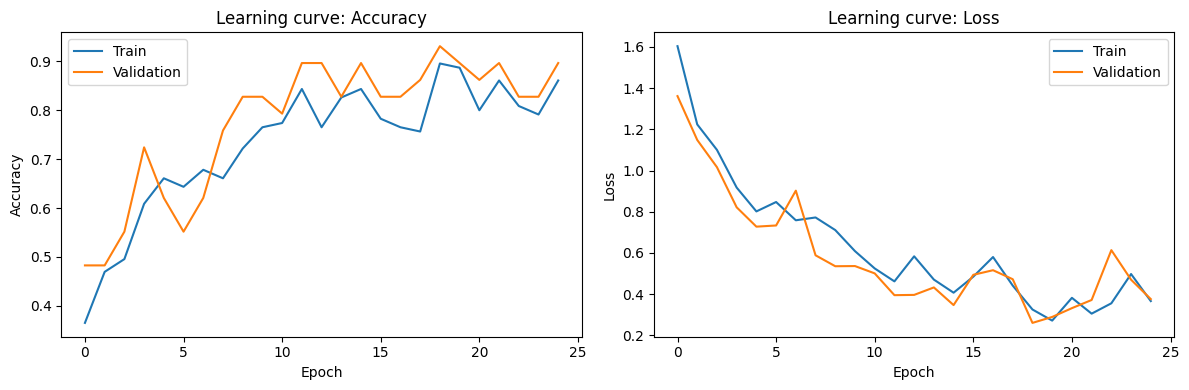

Test loss: 0.4360 | Test accuracy: 83.33%
              precision    recall  f1-score   support

       CamOn       0.75      1.00      0.86         6
           J       1.00      0.50      0.67         6
     TamBiet       0.83      0.83      0.83         6
     XinChao       0.86      1.00      0.92         6
      XinLoi       1.00      0.67      0.80         6
           Z       0.75      1.00      0.86         6

    accuracy                           0.83        36
   macro avg       0.87      0.83      0.82        36
weighted avg       0.87      0.83      0.82        36



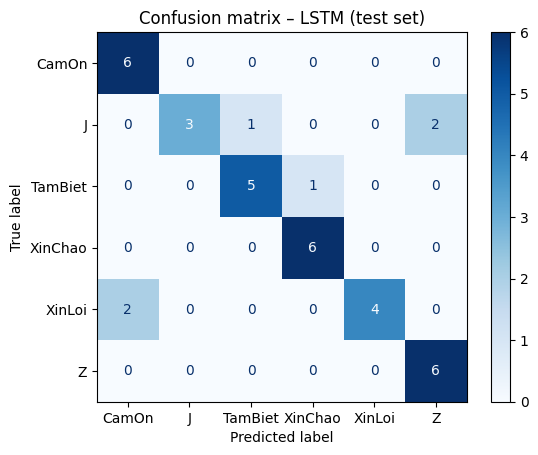

Đã lưu model/lstm/action_model.h5 và labels.json


/Users/huunghia/Project_gr6/venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set(title='Learning curve: Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set(title='Learning curve: Loss', xlabel='Epoch', ylabel='Loss')
axes[1].legend()
plt.tight_layout(); plt.show()

test_loss, test_accuracy = model.evaluate(X_test, tf.keras.utils.to_categorical(y_test, len(actions)), verbose=0)
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.2%}')
print(classification_report(y_test, y_pred, target_names=actions, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=actions, cmap='Blues')
plt.title('Confusion matrix – LSTM (test set)'); plt.show()

MODEL_DIR.mkdir(parents=True, exist_ok=True)
model.save(MODEL_DIR / 'action_model.h5')
(MODEL_DIR / 'labels.json').write_text(json.dumps(actions, ensure_ascii=False), encoding='utf-8')
print('Đã lưu model/lstm/action_model.h5 và labels.json')